In [6]:
# load the csv as a df 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import os 
cwd = os.getcwd()

# Load the dataset
# Make sure your CSV file is in the same directory as the script
df = pd.read_csv(os.path.join(cwd, 'c1c3000_features_extended.csv'), index_col= 'unique_id')
# Prepare the data for analysis
# Drop the 'label' column as it's an identifier, not a feature
features = df.drop('label', axis=1)


In [16]:
df.columns

Index(['label', 'area', 'perimeter', 'solidity', 'extent', 'mean_intensity',
       'max_intensity', 'min_intensity', 'eccentricity', 'major_axis_length',
       'minor_axis_length', 'orientation', 'circularity', 'intensity_std',
       'glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation',
       'cell_height_y', 'mean_dist_to_5_neighbors', 'n_chromocenters',
       'mean_chromocenter_area', 'chromocenter_area_fraction'],
      dtype='object')

In [7]:
features.head()
# features.shape

,area,perimeter,solidity,extent,mean_intensity,max_intensity,min_intensity,eccentricity,major_axis_length,minor_axis_length,...,intensity_std,glcm_contrast,glcm_homogeneity,glcm_energy,glcm_correlation,cell_height_y,mean_dist_to_5_neighbors,n_chromocenters,mean_chromocenter_area,chromocenter_area_fraction
unique_id,,,,,,,,,,,,,,,,,,,,,
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data\C1-C30000.png_cell_1,762.0,105.941125,0.963338,0.814103,119.308399,255.0,12.0,0.706185,37.446909,26.513436,...,57.862840,1271.915761,0.041787,0.028273,0.806814,11.828084,67.536428,6,53.666667,0.422572
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data\C1-C30000.png_cell_2,1191.0,126.083261,0.981054,0.847084,106.036944,255.0,9.0,0.254669,39.663566,38.355794,...,50.464978,1125.891587,0.039730,0.023207,0.774130,18.047019,59.976544,16,28.750000,0.386230
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data\C1-C30000.png_cell_3,1177.0,128.325902,0.974338,0.797425,88.415463,206.0,8.0,0.579887,43.033066,35.058908,...,34.960882,937.094190,0.043736,0.024427,0.604410,19.292268,60.765543,10,55.700000,0.473237
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data\C1-C30000.png_cell_4,697.0,103.840620,0.969402,0.757609,145.647059,255.0,18.0,0.822307,40.011962,22.768600,...,54.909253,1337.267062,0.047559,0.030873,0.769421,9.868006,71.669982,11,28.272727,0.446198
C:\Users\shiva\OneDrive\Desktop\MASK-R-CNN-Vision-Biology-Lab\image and seg data\C1-C30000.png_cell_5,395.0,80.526912,0.940476,0.707885,73.962025,167.0,9.0,0.772653,29.112273,18.481294,...,29.522719,725.442971,0.069568,0.041007,0.571550,7.769620,53.337739,8,21.000000,0.425316


In [8]:
num_features = len(features.columns)
num_cols = 4
num_rows = int(np.ceil(num_features / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(features.columns):
    sns.violinplot(y=features[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_ylabel('')

# Hide any unused subplots
for j in range(num_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('extended_feature_violins.png')
plt.close()
print("Saved feature distribution violin plots as 'extended_feature_violins.png'")

Saved feature distribution violin plots as 'extended_feature_violins.png'


In [9]:

# --- 2. Perform PCA and find components for 95% variance ---
print("\n--- Performing Principal Component Analysis (PCA) ---")
# Scale the features before applying PCA
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply PCA
pca = PCA()
pca.fit(features_scaled)




--- Performing Principal Component Analysis (PCA) ---


,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [10]:

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components for 95% variance
n_components_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
print(f"Number of principal components needed to explain 95% of the variance: {n_components_95}")

Number of principal components needed to explain 95% of the variance: 10


Saved PCA explained variance plot as 'pca_explained_variance.png'


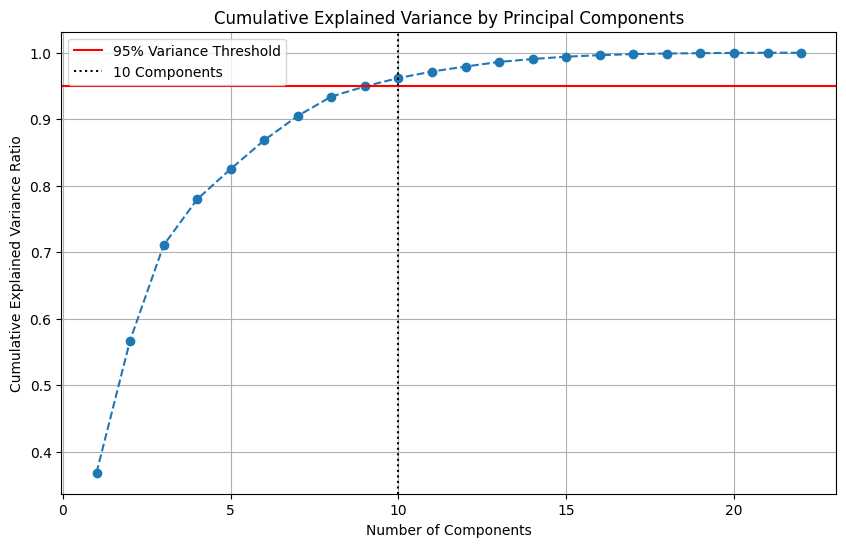

In [12]:
# Plot the explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variance Threshold')
plt.axvline(x=n_components_95, color='k', linestyle=':', label=f'{n_components_95} Components')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.legend()
plt.grid(True)
print("Saved PCA explained variance plot as 'pca_explained_variance.png'")



--- Generating Pairwise Plots for the First 3 PCs ---
Saved pairwise PC plots as 'pc_pairplots.png'


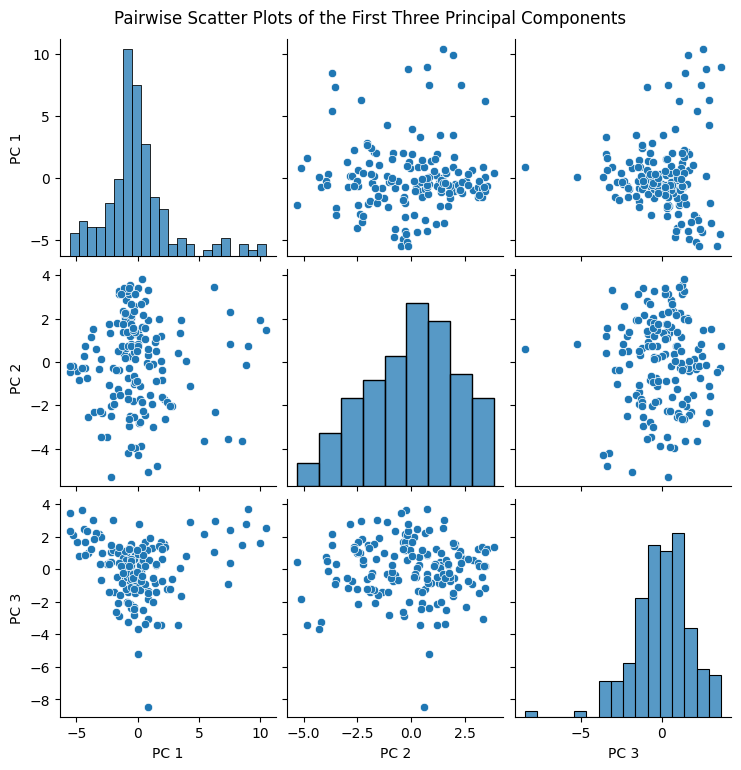

In [13]:

# --- 3. Create pairwise plots for the first three PCs ---
print("\n--- Generating Pairwise Plots for the First 3 PCs ---")
# Get the first 3 principal components
pca_3 = PCA(n_components=3)
principal_components = pca_3.fit_transform(features_scaled)
pc_df = pd.DataFrame(data=principal_components, columns=['PC 1', 'PC 2', 'PC 3'])

# Create pairplot
sns.pairplot(pc_df)
plt.suptitle('Pairwise Scatter Plots of the First Three Principal Components', y=1.02)
plt.savefig('extended_pc_pairplots.png')
# plt.close()
print("Saved pairwise PC plots as 'pc_pairplots.png'")



--- Generating Feature Correlation Heatmap ---
Saved feature correlation heatmap as 'feature_correlation_heatmap.png'


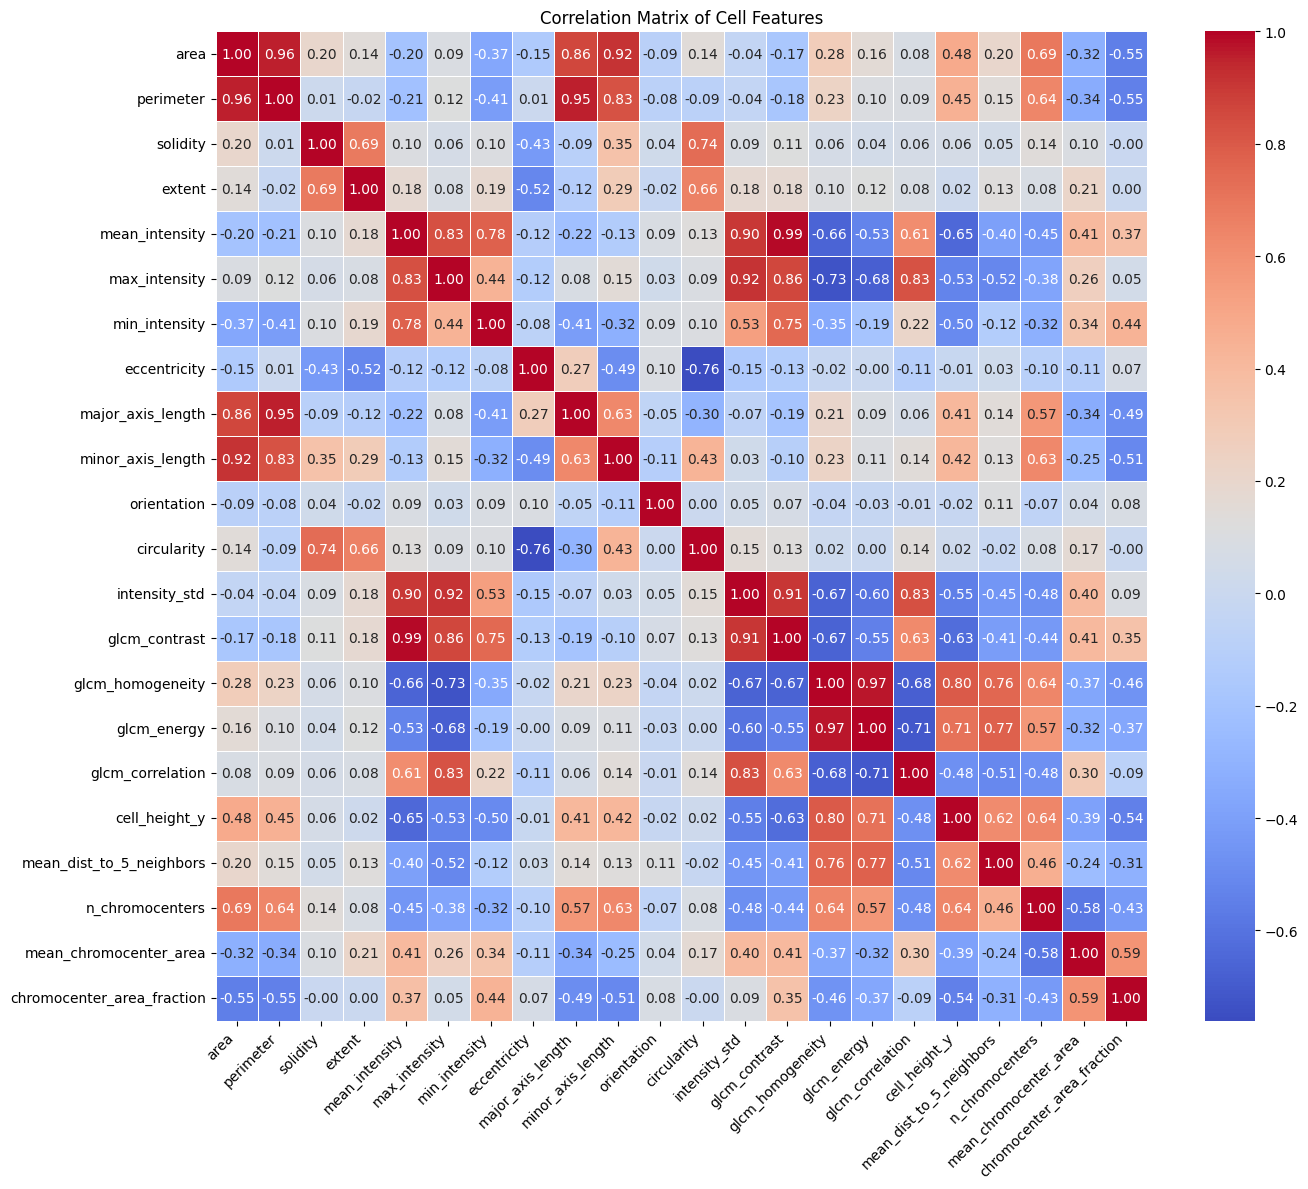

In [15]:

# --- 4. Create a correlation plot for all features ---
print("\n--- Generating Feature Correlation Heatmap ---")
# Calculate the correlation matrix
corr_matrix = features.corr()

# Create the heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix of Cell Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('extended_feature_correlation_heatmap.png')
# plt.close()
print("Saved feature correlation heatmap as 'feature_correlation_heatmap.png'")